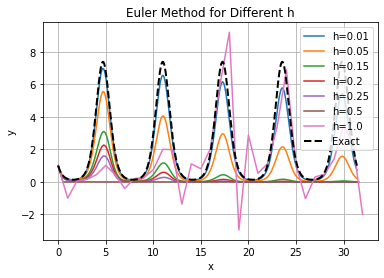

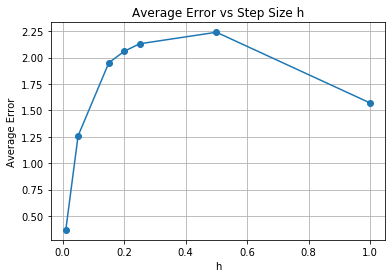

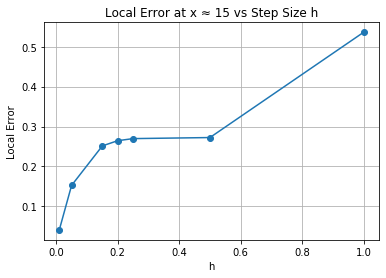


Comparison of y near x ≈ 15:
h = 0.01 | y ≈ 0.231440
h = 0.05 | y ≈ 0.119869
h = 0.15 | y ≈ 0.020921
h =  0.2 | y ≈ 0.007903
h = 0.25 | y ≈ 0.002662
h =  0.5 | y ≈ 0.000000
h =  1.0 | y ≈ 0.808593


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Differential equation
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# Euler method
def euler_method(h, x0=0, y0=1, x_end=10*np.pi):
    x_vals = np.arange(x0, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = y0

    for i in range(len(x_vals) - 1):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])

    return x_vals, y_vals

# Step sizes
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 1.0]

avg_errors = []
local_errors = []
y_at_15 = []

# Exact reference
x_exact = np.linspace(0, 10*np.pi, 1000)
y_true = y_exact(x_exact)

# -----------------------------
# Plot 1: Euler solutions
# -----------------------------
plt.figure()

for h in h_values:
    x, y = euler_method(h)

    # Interpolate exact solution to match grid
    y_true_interp = y_exact(x)

    # Average error
    avg_error = np.mean(np.abs(y - y_true_interp))
    avg_errors.append(avg_error)

    # Value near x = 15
    idx_15 = np.argmin(np.abs(x - 15))
    y_at_15.append(y[idx_15])

    # Local error at x ≈ 15
    local_error = abs(y[idx_15] - y_exact(x[idx_15]))
    local_errors.append(local_error)

    plt.plot(x, y, label=f"h={h}")

# Plot Euler's Method for each value of h
plt.plot(x_exact, y_true, 'k--', linewidth=2, label="Exact")

plt.title("Euler Method for Different h")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# Plot 2: Average error between runs vs h
plt.figure()

plt.plot(h_values, avg_errors, 'o-')
plt.title("Average Error vs Step Size h")
plt.xlabel("h")
plt.ylabel("Average Error")
plt.grid()

plt.show()

# Plot 3: Local error at x ≈ 15 for each run, local error vs h
plt.figure()

plt.plot(h_values, local_errors, 'o-')
plt.title("Local Error at x ≈ 15 vs Step Size h")
plt.xlabel("h")
plt.ylabel("Local Error")
plt.grid()

plt.show()

# Print comparison at x ≈ 15
print("\nComparison of y near x ≈ 15:")
for i, h in enumerate(h_values):
    print(f"h = {h:>4} | y ≈ {y_at_15[i]:.6f}")

h = 0.01 | worst-case bound satisfied: True | stable fraction of interval: 0.5000 | max |g(x,h)| = 1.0200
h = 0.05 | worst-case bound satisfied: True | stable fraction of interval: 0.5000 | max |g(x,h)| = 1.1000
h = 0.15 | worst-case bound satisfied: True | stable fraction of interval: 0.5000 | max |g(x,h)| = 1.3000
h =  0.2 | worst-case bound satisfied: True | stable fraction of interval: 0.5000 | max |g(x,h)| = 1.4000
h = 0.25 | worst-case bound satisfied: True | stable fraction of interval: 0.5000 | max |g(x,h)| = 1.5000
h =  0.5 | worst-case bound satisfied: True | stable fraction of interval: 0.5000 | max |g(x,h)| = 2.0000
h =  1.0 | worst-case bound satisfied: False | stable fraction of interval: 0.4990 | max |g(x,h)| = 3.0000


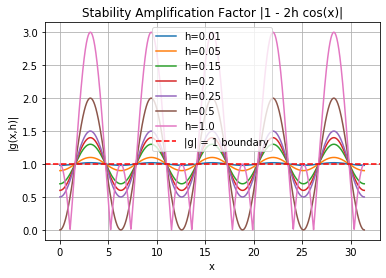

<Figure size 720x432 with 0 Axes>

In [7]:
# Stability Analysis addendum
def lambda_function(x):
    return -2 * np.cos(x)

def euler_amplification(x, h):
    return 1 + h * lambda_function(x)   # = 1 - 2h cos(x)

def stability_analysis(h, x0=0, x_end=10*np.pi, num_points=2000):
    """
    Frozen-coefficient stability analysis for:
        y' = -2 y cos(x)

    Uses:
        lambda(x) = df/dy = -2 cos(x)
        g(x,h) = 1 + h*lambda(x) = 1 - 2h cos(x)

    Stability condition:
        |g(x,h)| < 1
    """
    x_vals = np.linspace(x0, x_end, num_points)
    lam_vals = lambda_function(x_vals)
    g_vals = euler_amplification(x_vals, h)

    stable_mask = np.abs(g_vals) < 1
    stable_fraction = np.mean(stable_mask)
    max_abs_g = np.max(np.abs(g_vals))

    return {
        "h": h,
        "x": x_vals,
        "lambda": lam_vals,
        "g": g_vals,
        "stable_mask": stable_mask,
        "stable_fraction": stable_fraction,
        "max_abs_g": max_abs_g,
        "worst_case_bound_satisfied": h < 1
    }

def print_stability_summary(h_values):

    for h in h_values:
        result = stability_analysis(h)
        print(f"h = {h:>4} | "
              f"worst-case bound satisfied: {result['worst_case_bound_satisfied']} | "
              f"stable fraction of interval: {result['stable_fraction']:.4f} | "
              f"max |g(x,h)| = {result['max_abs_g']:.4f}")
        
print_stability_summary(h_values)

# Plot
def plot_stability_vs_x(h_values, x0=0, x_end=10*np.pi, num_points=2000):
    plt.figure()

    for h in h_values:
        result = stability_analysis(h, x0, x_end, num_points)
        plt.plot(result["x"], np.abs(result["g"]), label=f"h={h}")

    plt.axhline(1, linestyle="--", color="red", label="|g| = 1 boundary")
    plt.title("Stability Amplification Factor |1 - 2h cos(x)|")
    plt.xlabel("x")
    plt.ylabel("|g(x,h)|")
    plt.legend()
    plt.grid()
    plt.figure(figsize=(10, 6))
    plt.show()
plot_stability_vs_x(h_values)

# Write Up

As h gets smaller, Euler's method solves the exact solution more closely, so the average error over the interval and the error near x = 15 start decreasing. This behavior happens because Euler's method has global error of order O(h), which means that the overall accumulated error is proportional to the step size, h. The larger h values skip over more of the oscillation in cos(x), so the numerical solution loses accuracy.